In [2]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score, roc_curve
)
from sklearn.base import clone
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import warnings
warnings.filterwarnings('ignore')   # supprimer les FutureWarnings de seaborn/pandas

from jmetal.operator.mutation import PolynomialMutation
from jmetal.operator.crossover import SBXCrossover
from jmetal.algorithm.multiobjective import NSGAII, SPEA2
from jmetal.core.solution import FloatSolution
from jmetal.util.termination_criterion import StoppingByEvaluations
from jmetal.util.solution import get_non_dominated_solutions
from jmetal.core.problem import Problem

# ── Constantes de couleur (cohérentes dans tout le notebook) ─────────────────
ALGO_COLORS    = {'NSGA-II': '#E8A82A', 'SPEA2': '#3B8BD4'}
SKLEARN_COLORS = {'Random Forest': '#5B4FCF', 'SVM': '#E8593C', 'C4.5': '#1D9E75'}
SKLEARN_MARKERS= {'Random Forest': 'D', 'SVM': '^', 'C4.5': 's'}
ALL_COLORS     = {**ALGO_COLORS, **SKLEARN_COLORS}
ALGO_ORDER     = ['Random Forest', 'SVM', 'C4.5', 'NSGA-II', 'SPEA2']
DATASETS       = ['Diabetes', 'Yeast']

print('Imports OK')

Imports OK


In [3]:
df_diabetes = pd.read_csv('diabetes.csv')
df_yeast    = pd.read_csv('yeast.csv')
print('Diabetes shape :', df_diabetes.shape)
print('Yeast    shape :', df_yeast.shape)

Diabetes shape : (768, 9)
Yeast    shape : (1484, 9)


In [4]:
class PartialClassificationProblem(Problem):
    def __init__(self, X, y):
        super().__init__()
        self.X = np.array(X, dtype=float)
        self.y = np.array(y, dtype=int)
        self.n_attributes = self.X.shape[1]

        mins = X.min(axis=0)
        maxs = X.max(axis=0)
        self.lower_bound = []
        self.upper_bound = []

        for i in range(self.n_attributes):
            # CORRECTION : .iloc[i] au lieu de [i] (évite le FutureWarning pandas)
            self.lower_bound.extend([float(mins.iloc[i]), float(mins.iloc[i])])
            self.upper_bound.extend([float(maxs.iloc[i]), float(maxs.iloc[i])])

    def number_of_variables(self) -> int:
        return 2 * self.n_attributes

    def number_of_objectives(self) -> int:
        return 3

    def number_of_constraints(self) -> int:
        return 0

    def evaluate(self, solution: FloatSolution) -> FloatSolution:
        variables = solution.variables
        y_pred = []
        for instance in self.X:
            rule_active = True
            for i in range(self.n_attributes):
                bi = variables[2 * i]
                bs = variables[2 * i + 1]
                if bi <= bs:            # attribut actif
                    if not (bi <= instance[i] <= bs):
                        rule_active = False
                        break
            y_pred.append(1 if rule_active else 0)

        if sum(y_pred) == 0:
            solution.objectives[0] = 0.0
            solution.objectives[1] = 0.0
            solution.objectives[2] = 0.0
        else:
            solution.objectives[0] = -precision_score(self.y, y_pred, zero_division=0)
            solution.objectives[1] = -recall_score(self.y,    y_pred, zero_division=0)
            solution.objectives[2] = -f1_score(self.y,        y_pred, zero_division=0)
        return solution

    def create_solution(self) -> FloatSolution:
        sol = FloatSolution(
            self.lower_bound, self.upper_bound,
            self.number_of_objectives(), self.number_of_constraints()
        )
        sol.variables = [
            random.uniform(self.lower_bound[i], self.upper_bound[i])
            for i in range(self.number_of_variables())
        ]
        return sol

    def name(self):
        return 'PartialClassificationProblem'

print('PartialClassificationProblem OK')

PartialClassificationProblem OK


# 4. Algorithmes Connus (Sklearn)

## 4.1 Pima Diabetes

In [5]:
zero_impossible_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_diabetes[zero_impossible_cols] = df_diabetes[zero_impossible_cols].replace(0, np.nan)
df_diabetes.fillna(df_diabetes.median(numeric_only=True), inplace=True)

X_diabetes = df_diabetes.drop('Outcome', axis=1)
y_diabetes  = df_diabetes['Outcome']

X_train_diabetes, X_test_diabetes, y_train_diabetes, y_test_diabetes = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42, stratify=y_diabetes
)

scaler_diabetes = StandardScaler()
X_train_diabetes_scaled = scaler_diabetes.fit_transform(X_train_diabetes)
X_test_diabetes_scaled  = scaler_diabetes.transform(X_test_diabetes)

rf_model  = RandomForestClassifier(n_estimators=100, random_state=42)
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
c45_model = DecisionTreeClassifier(criterion='entropy', random_state=42)

model_configs_diabetes = {
    'Random Forest': (rf_model,  X_train_diabetes,        X_test_diabetes),
    'SVM':           (svm_model, X_train_diabetes_scaled, X_test_diabetes_scaled),
    'C4.5':          (c45_model, X_train_diabetes,        X_test_diabetes),
}

results_diabetes = {}
for name, (model, X_tr, X_te) in model_configs_diabetes.items():
    model.fit(X_tr, y_train_diabetes)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    cv_sc  = cross_val_score(model, X_tr, y_train_diabetes, cv=5, scoring='accuracy')
    results_diabetes[name] = {
        'Accuracy': accuracy_score(y_test_diabetes, y_pred),
        'ROC AUC':  roc_auc_score(y_test_diabetes, y_prob),
        'CV Mean':  cv_sc.mean(), 'CV Std': cv_sc.std(),
        'y_pred': y_pred, 'y_prob': y_prob, 'model': model
    }
    print(f'  {name:15s}  Accuracy={results_diabetes[name]["Accuracy"]:.3f}  AUC={results_diabetes[name]["ROC AUC"]:.3f}')

print('\nDiabetes sklearn OK')

  Random Forest    Accuracy=0.779  AUC=0.819
  SVM              Accuracy=0.740  AUC=0.796
  C4.5             Accuracy=0.675  AUC=0.639

Diabetes sklearn OK


## 4.2 Yeast

In [6]:
zero_impossible_cols_y = ['Mit', 'Vac', 'Nuc']
df_yeast[zero_impossible_cols_y] = df_yeast[zero_impossible_cols_y].replace(0, np.nan)
df_yeast.fillna(df_yeast.median(numeric_only=True), inplace=True)

for col in df_yeast.select_dtypes(include='object').columns:
    if col != 'Output':
        df_yeast[col] = LabelEncoder().fit_transform(df_yeast[col])

X_yeast = df_yeast.drop('Output', axis=1)
y_yeast  = df_yeast['Output']

X_train_yeast, X_test_yeast, y_train_yeast, y_test_yeast = train_test_split(
    X_yeast, y_yeast, test_size=0.2, random_state=42, stratify=y_yeast
)

scaler_yeast = StandardScaler()
X_train_yeast_scaled = scaler_yeast.fit_transform(X_train_yeast)
X_test_yeast_scaled  = scaler_yeast.transform(X_test_yeast)

rf_model2  = RandomForestClassifier(n_estimators=100, random_state=42)
svm_model2 = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
c45_model2 = DecisionTreeClassifier(criterion='entropy', random_state=42)

model_configs_yeast = {
    'Random Forest': (rf_model2,  X_train_yeast,        X_test_yeast),
    'SVM':           (svm_model2, X_train_yeast_scaled, X_test_yeast_scaled),
    'C4.5':          (c45_model2, X_train_yeast,        X_test_yeast),
}

results_yeast = {}
for name, (model, X_tr, X_te) in model_configs_yeast.items():
    model.fit(X_tr, y_train_yeast)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    cv_sc  = cross_val_score(model, X_tr, y_train_yeast, cv=5, scoring='accuracy')
    results_yeast[name] = {
        'Accuracy': accuracy_score(y_test_yeast, y_pred),
        'ROC AUC':  roc_auc_score(y_test_yeast, y_prob),
        'CV Mean':  cv_sc.mean(), 'CV Std': cv_sc.std(),
        'y_pred': y_pred, 'y_prob': y_prob, 'model': model
    }
    print(f'  {name:15s}  Accuracy={results_yeast[name]["Accuracy"]:.3f}  AUC={results_yeast[name]["ROC AUC"]:.3f}')

print('\nYeast sklearn OK')

  Random Forest    Accuracy=0.771  AUC=0.811
  SVM              Accuracy=0.781  AUC=0.778
  C4.5             Accuracy=0.774  AUC=0.710

Yeast sklearn OK


# 5. Fonctions utilitaires

In [7]:
def run_algorithm(algorithm_class, problem, population_size, max_evaluations,
                  crossover_prob=0.9, mutation_prob=None):
    n_vars = problem.number_of_variables()
    if mutation_prob is None:
        mutation_prob = 1.0 / n_vars

    crossover   = SBXCrossover(probability=crossover_prob, distribution_index=20)
    mutation    = PolynomialMutation(probability=mutation_prob, distribution_index=20)
    try:
        termination = StoppingByEvaluations(max_evaluations=max_evaluations)
    except TypeError:
        termination = StoppingByEvaluations(max=max_evaluations)

    algorithm = algorithm_class(
        problem=problem,
        population_size=population_size,
        offspring_population_size=population_size,
        mutation=mutation, crossover=crossover,
        termination_criterion=termination
    )
    algorithm.run()
    try:
        raw = algorithm.result()
    except AttributeError:
        raw = algorithm.get_result()

    pareto_front = get_non_dominated_solutions(raw)
    return pareto_front, algorithm


## 5-2 HYPERVOLUME

In [8]:
def hypervolume_2d(pareto_front, ref=(0.0, 0.0)):
    if not pareto_front:
        return 0.0

    # Extraire (precision, recall) depuis les objectifs négatifs
    points = [(-s.objectives[0], -s.objectives[1]) for s in pareto_front]

    # Trier par précision décroissante
    pts = sorted(points, key=lambda p: (-p[0], -p[1]))

    # Garder uniquement les solutions non-dominées dans le plan 2D :
    # une solution A domine B si A.prec >= B.prec ET A.rec >= B.rec
    nd2d, max_rec = [], -np.inf
    for prec, rec in pts:
        if rec > max_rec:
            nd2d.append((prec, rec))
            max_rec = rec

    # Calcul HV par sweep-line :
    # chaque point couvre le rectangle entre lui et le point suivant
    hv = 0.0
    ref_x, ref_y = ref
    for i, (prec, rec) in enumerate(nd2d):
        next_prec = nd2d[i + 1][0] if i + 1 < len(nd2d) else ref_x
        hv += (prec - next_prec) * (rec - ref_y)
    return hv

## 5-3 Evaluation

In [9]:
def evaluate_solution_on_set(solution, X_set, y_set):
    """
    Applique la règle hyperboxe encodée dans `solution` sur X_set / y_set.
    Retourne un dict {Precision, Recall, F1}.
    """
    variables = solution.variables
    n_attr    = len(variables) // 2
    X_arr, y_arr = np.array(X_set, dtype=float), np.array(y_set, dtype=int)

    y_pred = []
    for instance in X_arr:
        active = True
        for i in range(n_attr):
            bi, bs = variables[2 * i], variables[2 * i + 1]
            if bi <= bs and not (bi <= instance[i] <= bs):
                active = False; break
        y_pred.append(1 if active else 0)

    if sum(y_pred) == 0:
        return {'Precision': 0.0, 'Recall': 0.0, 'F1': 0.0}
    return {
        'Precision': precision_score(y_arr, y_pred, zero_division=0),
        'Recall':    recall_score(y_arr,    y_pred, zero_division=0),
        'F1':        f1_score(y_arr,         y_pred, zero_division=0),
    }

print('Fonctions utilitaires OK')

Fonctions utilitaires OK


## 6. Tuning de la taille de population

fais teste pour 2000, après 30 mn trop longtemps , ensuite à 500 plus de 30 mn ainsi redescendu à 200

In [16]:
POPULATION_SIZES = [50, 76, 100]   
N_RUNS           = 20               
MAX_EVALUATIONS  = 100

datasets_train = {
    'Diabetes': (X_train_diabetes, y_train_diabetes),
    'Yeast':    (X_train_yeast,    y_train_yeast),
}
algorithms_dict = {'NSGA-II': NSGAII, 'SPEA2': SPEA2}

# Structure : tuning_hv[dataset][algo][pop_size] = [hv_run1, ..., hv_run20]
tuning_hv = {
    ds: {ag: {ps: [] for ps in POPULATION_SIZES} for ag in algorithms_dict}
    for ds in datasets_train
}

print(f'Démarrage du tuning : {len(POPULATION_SIZES)} tailles × {len(algorithms_dict)} algos × {len(datasets_train)} datasets × {N_RUNS} runs')
print(f'Total runs : {len(POPULATION_SIZES) * len(algorithms_dict) * len(datasets_train) * N_RUNS}\n')

for dataset_name, (X, y) in datasets_train.items():
    problem = PartialClassificationProblem(X, y)
    print(f'\n── Dataset : {dataset_name} ──')

    for algo_name, algo_class in algorithms_dict.items():
        for pop_size in POPULATION_SIZES:
            hvs = []
            for run in range(N_RUNS):
                pf, _ = run_algorithm(algo_class, problem,
                                      population_size=pop_size,
                                      max_evaluations=MAX_EVALUATIONS)
                hvs.append(hypervolume_2d(pf))
            tuning_hv[dataset_name][algo_name][pop_size] = hvs
            print(f'  {algo_name} pop={pop_size:3d} → HV moyen={np.mean(hvs):.4f}  std={np.std(hvs):.4f}')

print('\n✓ Tuning terminé')

[2026-03-27 18:50:54,880] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:50:54,882] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 18:50:54,972] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:50:54,973] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 18:50:55,065] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:50:55,066] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:50:55,066] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


Démarrage du tuning : 3 tailles × 2 algos × 2 datasets × 20 runs
Total runs : 240


── Dataset : Diabetes ──


[2026-03-27 18:50:55,146] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:50:55,146] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 18:50:55,214] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:50:55,215] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:50:55,215] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 18:50:55,325] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:50:55,326] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 18:50:55,436] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:50:55,437] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:50:55,438] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 18:50:55,546] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:50:55,546] [jmetal.core.al

  NSGA-II pop= 50 → HV moyen=0.3594  std=0.0952


[2026-03-27 18:50:58,834] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:50:58,835] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:50:58,836] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 18:50:58,972] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:50:58,972] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 18:50:59,099] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:50:59,100] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:50:59,100] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 18:50:59,204] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:50:59,205] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 18:50:59,319] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:50:59,319] [jmetal.core.algorithm] [DEBUG

...

  SPEA2 pop= 50 → HV moyen=0.2807  std=0.1125


[2026-03-27 18:52:35,384] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:52:35,385] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:52:35,386] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 18:52:35,477] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:52:35,478] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 18:52:39,352] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:52:39,353] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:52:39,354] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 18:52:39,466] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:52:39,466] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 18:52:42,359] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:52:42,360] [jmetal.core.algorithm] [DEBUG

  SPEA2 pop= 76 → HV moyen=0.3551  std=0.0472


[2026-03-27 18:53:43,813] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:53:43,814] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 18:53:43,814] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:53:43,815] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:53:43,816] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 18:53:43,941] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:53:43,942] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 18:53:43,943] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:53:43,943] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:53:43,944] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 18:53:44,124] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:53:44,125] [jmetal.core.al

  SPEA2 pop=100 → HV moyen=0.3157  std=0.0840

✓ Tuning terminé


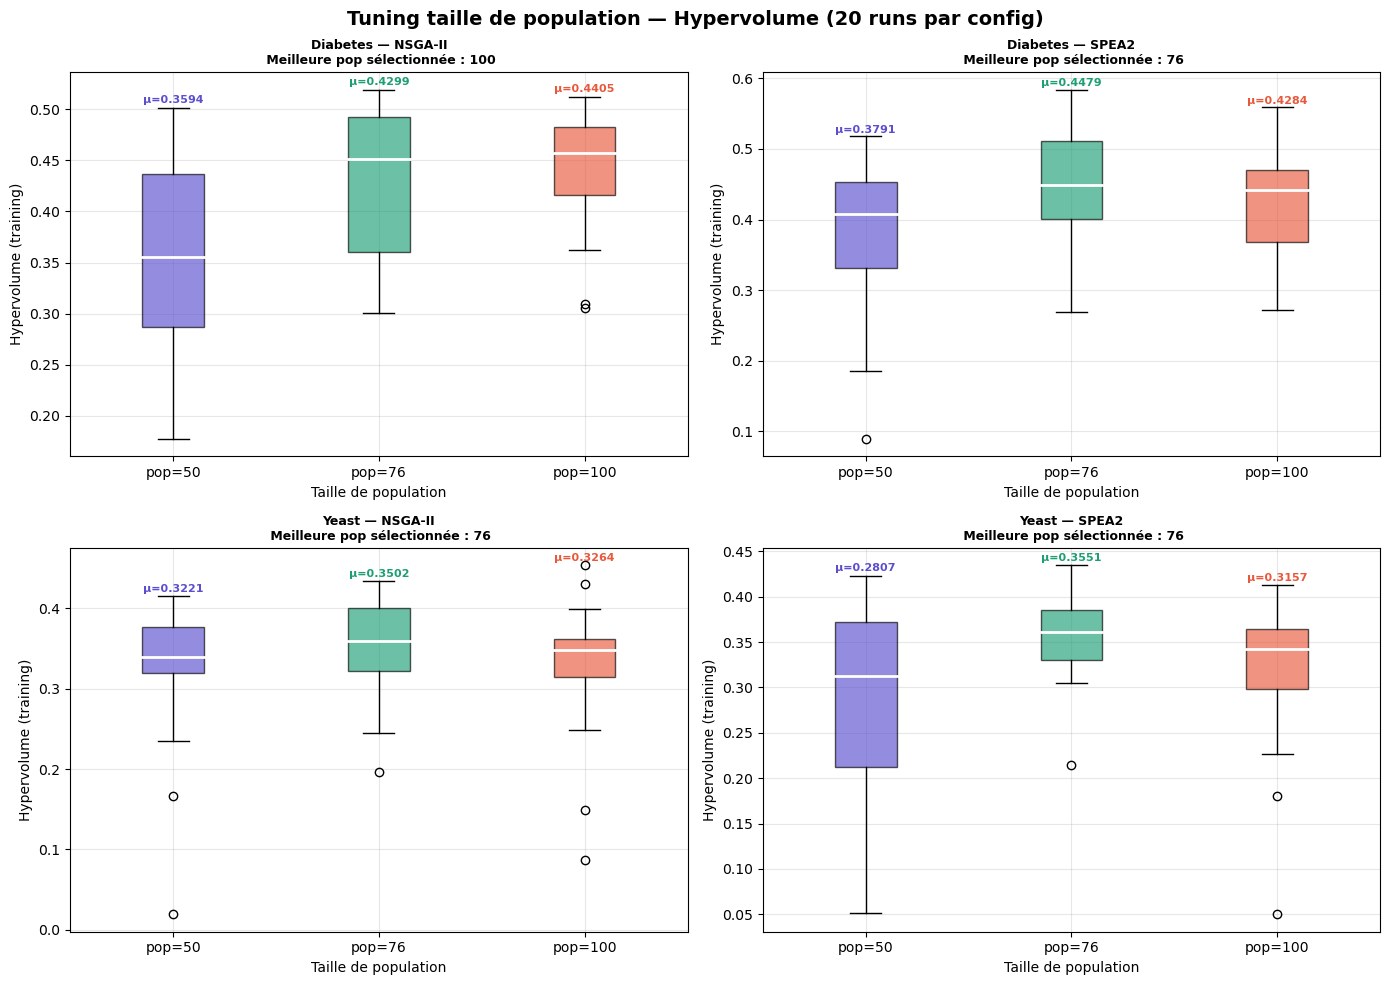

Figure sauvegardée : tuning_hypervolume_boxplots.png


In [18]:
# ── Boxplots HV - Tuning ─────────────────────────────────────────────────
BOX_COLORS = ['#5B4FCF', '#1D9E75', '#E8593C']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Tuning taille de population — Hypervolume (20 runs par config)',
             fontsize=14, fontweight='bold')

for row, dataset_name in enumerate(['Diabetes', 'Yeast']):
    for col, algo_name in enumerate(['NSGA-II', 'SPEA2']):
        ax = axes[row][col]
        data   = [tuning_hv[dataset_name][algo_name][ps] for ps in POPULATION_SIZES]
        labels = [f'pop={ps}' for ps in POPULATION_SIZES]
        means  = [np.mean(d) for d in data]
        best_ps = POPULATION_SIZES[int(np.argmax(means))]

        bp = ax.boxplot(data, patch_artist=True, labels=labels,
                        medianprops=dict(color='white', linewidth=2))
        for patch, color in zip(bp['boxes'], BOX_COLORS):
            patch.set_facecolor(color); patch.set_alpha(0.65)

        # Annoter les moyennes
        for i, (m, col_c) in enumerate(zip(means, BOX_COLORS), 1):
            ax.text(i, max(data[i-1]) + 0.005, f'μ={m:.4f}',
                    ha='center', fontsize=8, color=col_c, fontweight='bold')

        ax.set_title(f'{dataset_name} — {algo_name}\n Meilleure pop sélectionnée : {best_ps}',
                     fontsize=9, fontweight='bold')
        ax.set_ylabel('Hypervolume (training)'); ax.set_xlabel('Taille de population')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('tuning_hypervolume_boxplots.png', dpi=150)
plt.show()
print('Figure sauvegardée : tuning_hypervolume_boxplots.png')

In [19]:
# ── Tableau récap tuning + sélection meilleure pop ───────────────────────
best_pop_size = {}   # best_pop_size[dataset][algo]
tuning_rows   = []

for dataset_name in datasets_train:
    best_pop_size[dataset_name] = {}
    for algo_name in algorithms_dict:
        means   = {ps: np.mean(tuning_hv[dataset_name][algo_name][ps]) for ps in POPULATION_SIZES}
        best_ps = max(means, key=means.get)
        best_pop_size[dataset_name][algo_name] = best_ps
        for ps in POPULATION_SIZES:
            hvs = tuning_hv[dataset_name][algo_name][ps]
            tuning_rows.append({
                'Dataset': dataset_name, 'Algorithme': algo_name,
                'Pop Size': ps,
                'HV Moyen': round(np.mean(hvs), 4),
                'HV Std':   round(np.std(hvs),  4),
                'HV Max':   round(np.max(hvs),  4),
                'HV Min':   round(np.min(hvs),  4),
                'Sélectionné': '✓' if ps == best_ps else ''
            })

df_tuning = pd.DataFrame(tuning_rows)
print('=== TABLEAU DE TUNING ===')
print(df_tuning.to_string(index=False))
print()
print('=== MEILLEURES TAILLES SÉLECTIONNÉES ===')
for ds, algo_ps in best_pop_size.items():
    for ag, ps in algo_ps.items():
        print(f'  {ds:10s} {ag:8s} → pop={ps}')

=== TABLEAU DE TUNING ===
 Dataset Algorithme  Pop Size  HV Moyen  HV Std  HV Max  HV Min Sélectionné
Diabetes    NSGA-II        50    0.3594  0.0952  0.5009  0.1774            
Diabetes    NSGA-II        76    0.4299  0.0737  0.5192  0.3001            
Diabetes    NSGA-II       100    0.4405  0.0587  0.5125  0.3056           ✓
Diabetes      SPEA2        50    0.3791  0.1134  0.5182  0.0893            
Diabetes      SPEA2        76    0.4479  0.0791  0.5838  0.2691           ✓
Diabetes      SPEA2       100    0.4284  0.0771  0.5594  0.2721            
   Yeast    NSGA-II        50    0.3221  0.0908  0.4157  0.0191            
   Yeast    NSGA-II        76    0.3502  0.0608  0.4341  0.1959           ✓
   Yeast    NSGA-II       100    0.3264  0.0846  0.4538  0.0869            
   Yeast      SPEA2        50    0.2807  0.1125  0.4230  0.0512            
   Yeast      SPEA2        76    0.3551  0.0472  0.4347  0.2143           ✓
   Yeast      SPEA2       100    0.3157  0.0840  0.4129  0.049

# 7. 20 Runs finaux (meilleure taille de population)

On relance 20 fois chaque algorithme avec la taille de population sélectionnée à l'étape 6. Chaque run donne un front de Pareto et son HV. On mémorise tout pour les Figures 1, 2 et 3.

In [20]:
# Structure : all_runs[dataset][algo] = [(hv, pareto_front), ...]
all_runs = {ds: {ag: [] for ag in algorithms_dict} for ds in datasets_train}

print('=== 20 RUNS FINAUX ===')
for dataset_name, (X, y) in datasets_train.items():
    problem = PartialClassificationProblem(X, y)
    print(f'\n── Dataset : {dataset_name} ──')
    for algo_name, algo_class in algorithms_dict.items():
        best_ps = best_pop_size[dataset_name][algo_name]
        print(f'  {algo_name}  pop={best_ps} (sélectionné au tuning)')
        for run in range(N_RUNS):
            pf, _ = run_algorithm(algo_class, problem,
                                  population_size=best_ps,
                                  max_evaluations=MAX_EVALUATIONS)
            hv = hypervolume_2d(pf)
            all_runs[dataset_name][algo_name].append((hv, pf))
            print(f'    run {run+1:2d}/{N_RUNS}  HV={hv:.4f}  front_size={len(pf)}')

print('\n✓ 20 runs finaux terminés')

[2026-03-27 18:57:56,792] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:57:56,794] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 18:57:56,977] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:57:56,977] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 18:57:56,978] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:57:56,978] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:57:56,979] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


=== 20 RUNS FINAUX ===

── Dataset : Diabetes ──
  NSGA-II  pop=100 (sélectionné au tuning)
    run  1/20  HV=0.4434  front_size=6


[2026-03-27 18:57:57,147] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:57:57,148] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 18:57:57,148] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:57:57,149] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:57:57,150] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 18:57:57,339] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:57:57,340] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 18:57:57,340] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:57:57,341] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:57:57,342] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


    run  2/20  HV=0.5332  front_size=5
    run  3/20  HV=0.4732  front_size=6


[2026-03-27 18:57:57,535] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:57:57,535] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met
[2026-03-27 18:57:57,536] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:57:57,537] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:57:57,538] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...


...

    run 18/20  HV=0.3960  front_size=3


[2026-03-27 18:59:48,873] [jmetal.core.algorithm] [DEBUG] Finished!
[2026-03-27 18:59:48,875] [jmetal.core.algorithm] [DEBUG] Creating initial set of solutions...
[2026-03-27 18:59:48,875] [jmetal.core.algorithm] [DEBUG] Evaluating solutions...
[2026-03-27 18:59:49,034] [jmetal.core.algorithm] [DEBUG] Initializing progress...
[2026-03-27 18:59:49,035] [jmetal.core.algorithm] [DEBUG] Running main loop until termination criteria is met


    run 19/20  HV=0.3220  front_size=4


[2026-03-27 18:59:52,915] [jmetal.core.algorithm] [DEBUG] Finished!


    run 20/20  HV=0.3403  front_size=6

✓ 20 runs finaux terminés


In [21]:
# ── Tableau récap HV — 20 runs finaux ────────────────────────────────────
hv_rows = []
for dataset_name in datasets_train:
    for algo_name in algorithms_dict:
        hvs     = [r[0] for r in all_runs[dataset_name][algo_name]]
        best_ps = best_pop_size[dataset_name][algo_name]
        hv_rows.append({
            'Dataset': dataset_name, 'Algorithme': algo_name,
            'Meilleure pop': best_ps,
            'HV Moyen': round(np.mean(hvs), 4),
            'HV Std':   round(np.std(hvs),  4),
            'HV Max':   round(np.max(hvs),  4),
            'HV Min':   round(np.min(hvs),  4),
        })

df_hv = pd.DataFrame(hv_rows)
print('=== RÉCAPITULATIF HYPERVOLUME (20 runs finaux) ===')
print(df_hv.to_string(index=False))

=== RÉCAPITULATIF HYPERVOLUME (20 runs finaux) ===
 Dataset Algorithme  Meilleure pop  HV Moyen  HV Std  HV Max  HV Min
Diabetes    NSGA-II            100    0.4370  0.0599  0.5332  0.2584
Diabetes      SPEA2             76    0.4366  0.0628  0.5282  0.2996
   Yeast    NSGA-II             76    0.3452  0.0758  0.4297  0.0827
   Yeast      SPEA2             76    0.3623  0.0611  0.4307  0.1339


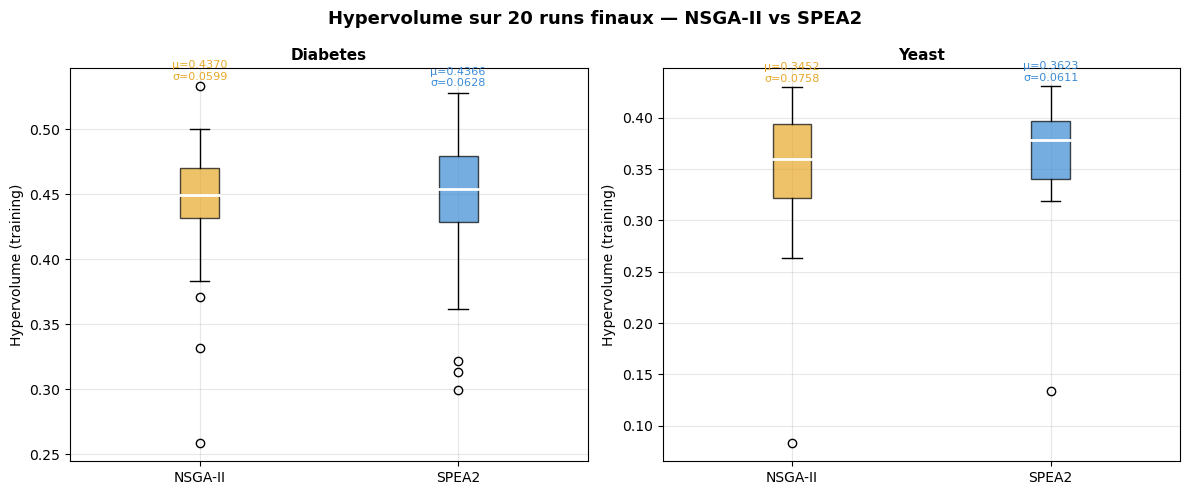

Figure sauvegardée : hv_boxplots_final_runs.png


In [22]:
# ── Boxplots HV — NSGA-II vs SPEA2 (20 runs finaux) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Hypervolume sur 20 runs finaux — NSGA-II vs SPEA2',
             fontsize=13, fontweight='bold')

for ax, dataset_name in zip(axes, ['Diabetes', 'Yeast']):
    data_nsga  = [r[0] for r in all_runs[dataset_name]['NSGA-II']]
    data_spea2 = [r[0] for r in all_runs[dataset_name]['SPEA2']]

    bp = ax.boxplot([data_nsga, data_spea2], patch_artist=True,
                    labels=['NSGA-II', 'SPEA2'],
                    medianprops=dict(color='white', linewidth=2))
    bp['boxes'][0].set_facecolor(ALGO_COLORS['NSGA-II']); bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(ALGO_COLORS['SPEA2']);   bp['boxes'][1].set_alpha(0.7)

    for i, (data, name) in enumerate([(data_nsga,'NSGA-II'),(data_spea2,'SPEA2')], 1):
        ax.text(i, max(data)+0.005,
                f'μ={np.mean(data):.4f}\nσ={np.std(data):.4f}',
                ha='center', fontsize=8, color=ALGO_COLORS[name])

    ax.set_title(dataset_name, fontsize=11, fontweight='bold')
    ax.set_ylabel('Hypervolume (training)'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hv_boxplots_final_runs.png', dpi=150)
plt.show()
print('Figure sauvegardée : hv_boxplots_final_runs.png')

# 8. Protocole de comparaison (Figures 1, 2, 3 + Test set)

## 8.1 Identification du meilleur front par algorithme

In [23]:
# Identifier le meilleur run (HV max) pour chaque (dataset, algo)
best_fronts    = {}   # best_fronts[dataset][algo]    = pareto_front
best_solutions = {}   # best_solutions[dataset][algo] = solution (meilleur F1 sur meilleur front)

for dataset_name in datasets_train:
    best_fronts[dataset_name]    = {}
    best_solutions[dataset_name] = {}
    for algo_name in algorithms_dict:
        runs    = all_runs[dataset_name][algo_name]
        best_i  = int(np.argmax([r[0] for r in runs]))
        best_hv, best_front = runs[best_i]
        best_fronts[dataset_name][algo_name] = best_front

        # Solution recommandée = meilleur F1 sur le meilleur front
        best_sol = max(best_front, key=lambda s: -s.objectives[2])
        best_solutions[dataset_name][algo_name] = best_sol

        prec = -best_sol.objectives[0]
        rec  = -best_sol.objectives[1]
        f1   = -best_sol.objectives[2]
        print(f'{dataset_name:10s} {algo_name:8s}  '
              f'Meilleur HV={best_hv:.4f}  '
              f'Best F1={f1:.4f}  P={prec:.4f}  R={rec:.4f}')

Diabetes   NSGA-II   Meilleur HV=0.5332  Best F1=0.5642  P=0.5134  R=0.6262
Diabetes   SPEA2     Meilleur HV=0.5282  Best F1=0.5169  P=0.3485  R=1.0000
Yeast      NSGA-II   Meilleur HV=0.4297  Best F1=0.5195  P=0.4684  R=0.5831
Yeast      SPEA2     Meilleur HV=0.4307  Best F1=0.5391  P=0.4871  R=0.6035


## 8.2 Figure 1 — Tous les fronts de Pareto (20 runs)

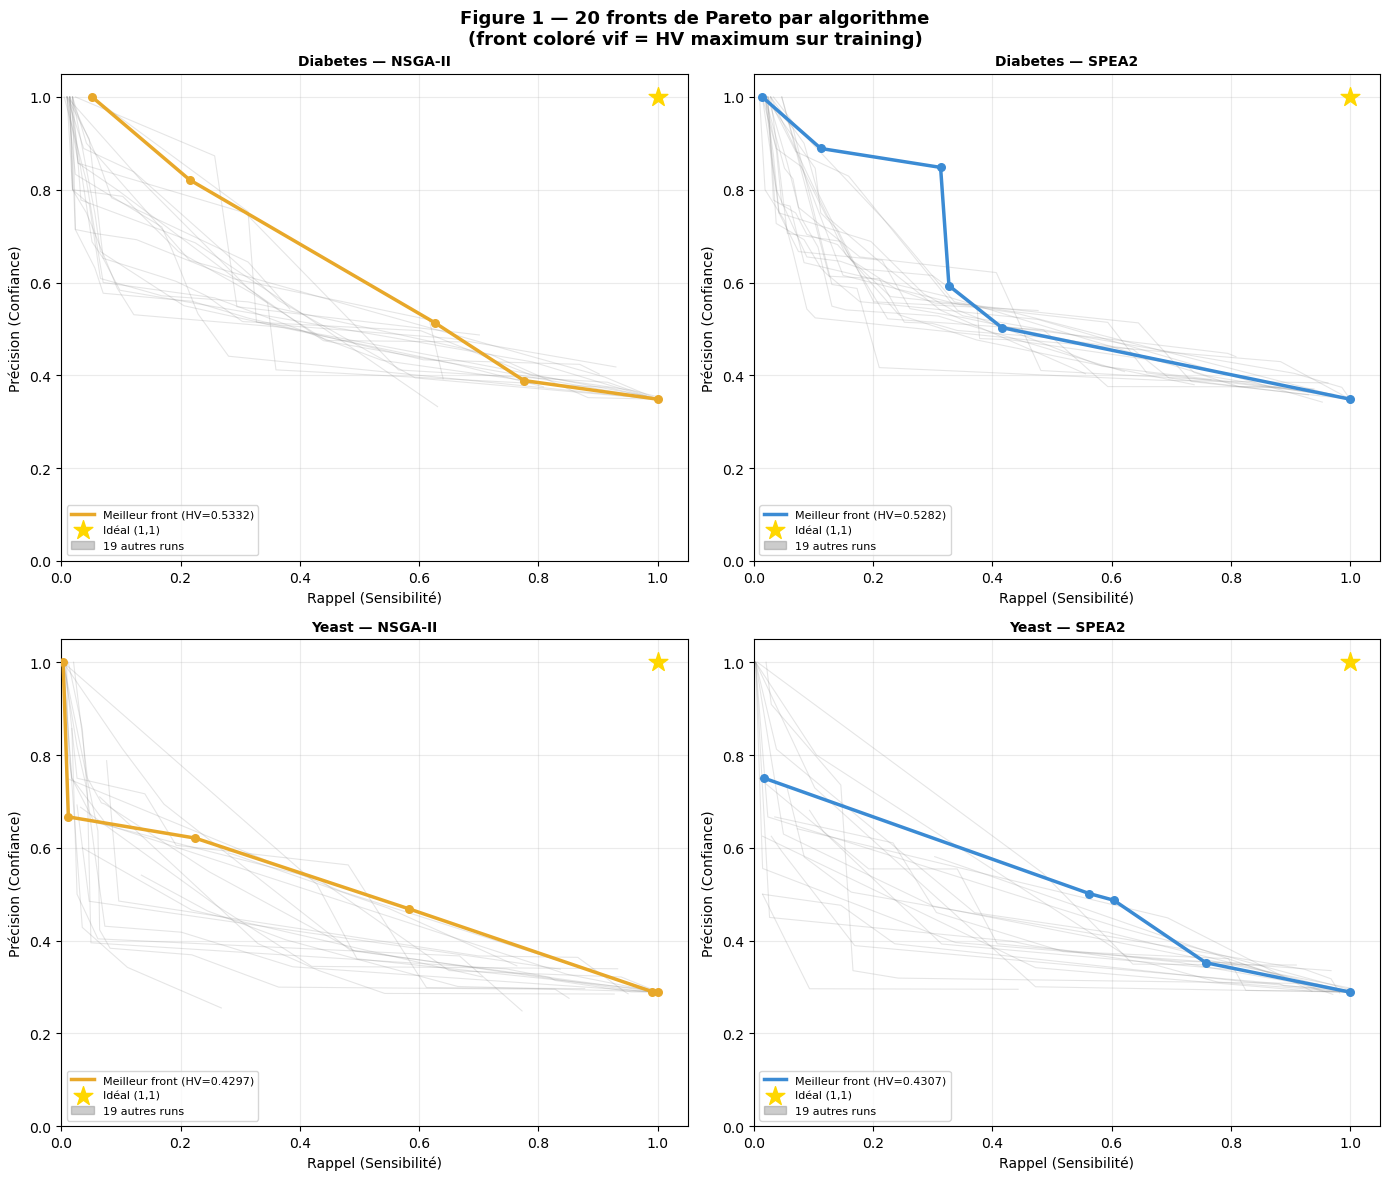

Figure 1 sauvegardée.


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Figure 1 — 20 fronts de Pareto par algorithme\n'
             '(front coloré vif = HV maximum sur training)',
             fontsize=13, fontweight='bold')

for row, dataset_name in enumerate(['Diabetes', 'Yeast']):
    for col, algo_name in enumerate(['NSGA-II', 'SPEA2']):
        ax    = axes[row][col]
        runs  = all_runs[dataset_name][algo_name]
        color = ALGO_COLORS[algo_name]
        best_i = int(np.argmax([r[0] for r in runs]))

        # Tous les fronts en gris clair (arrière-plan)
        for i, (hv, front) in enumerate(runs):
            pts = sorted([(-s.objectives[1], -s.objectives[0]) for s in front], key=lambda p: p[0])
            if pts:
                xs, ys = zip(*pts)
                ax.plot(xs, ys, color='gray', alpha=0.2, linewidth=0.8)

        # Meilleur front en couleur vive (premier plan)
        _, best_front = runs[best_i]
        best_hv       = runs[best_i][0]
        best_pts = sorted([(-s.objectives[1], -s.objectives[0]) for s in best_front], key=lambda p: p[0])
        if best_pts:
            bxs, bys = zip(*best_pts)
            ax.plot(bxs, bys, color=color, linewidth=2.5, zorder=5,
                    label=f'Meilleur front (HV={best_hv:.4f})')
            ax.scatter(bxs, bys, color=color, s=30, zorder=6)

        # Point idéal
        ax.scatter([1], [1], marker='*', s=200, color='gold', zorder=7, label='Idéal (1,1)')

        grey_patch = mpatches.Patch(color='gray', alpha=0.4, label=f'{N_RUNS-1} autres runs')
        handles, labels_l = ax.get_legend_handles_labels()
        ax.legend(handles + [grey_patch], labels_l + [grey_patch.get_label()], fontsize=8)

        ax.set_title(f'{dataset_name} — {algo_name}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Rappel (Sensibilité)'); ax.set_ylabel('Précision (Confiance)')
        ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('figure1_all_pareto_fronts.png', dpi=150)
plt.show()
print('Figure 1 sauvegardée.')

## 8.3 Performances sklearn sur le TRAINING

In [25]:
# Calcul des métriques sklearn sur le TRAINING (pour Figure 2)
sklearn_train = {}   # sklearn_train[dataset][model] = {Precision, Recall, F1}

for dataset_name in ['Diabetes', 'Yeast']:
    sklearn_train[dataset_name] = {}
    results_sk = results_diabetes if dataset_name == 'Diabetes' else results_yeast
    X_tr    = X_train_diabetes        if dataset_name == 'Diabetes' else X_train_yeast
    X_tr_sc = X_train_diabetes_scaled if dataset_name == 'Diabetes' else X_train_yeast_scaled
    y_tr    = y_train_diabetes        if dataset_name == 'Diabetes' else y_train_yeast

    for model_name, res in results_sk.items():
        X_input = X_tr_sc if model_name == 'SVM' else X_tr
        y_pred_tr = res['model'].predict(X_input)
        sklearn_train[dataset_name][model_name] = {
            'Precision': precision_score(y_tr, y_pred_tr, zero_division=0),
            'Recall':    recall_score(y_tr,    y_pred_tr, zero_division=0),
            'F1':        f1_score(y_tr,         y_pred_tr, zero_division=0),
        }

print('Métriques sklearn sur training :')
for ds in ['Diabetes', 'Yeast']:
    print(f'\n  {ds}')
    for m, vals in sklearn_train[ds].items():
        print(f'    {m:15s}  P={vals["Precision"]:.3f}  R={vals["Recall"]:.3f}  F1={vals["F1"]:.3f}')

Métriques sklearn sur training :

  Diabetes
    Random Forest    P=1.000  R=1.000  F1=1.000
    SVM              P=0.837  R=0.673  F1=0.746
    C4.5             P=1.000  R=1.000  F1=1.000

  Yeast
    Random Forest    P=1.000  R=1.000  F1=1.000
    SVM              P=0.742  R=0.411  F1=0.529
    C4.5             P=1.000  R=1.000  F1=1.000


## 8.4 Figure 2 — Meilleur front Pareto vs sklearn (TRAINING)

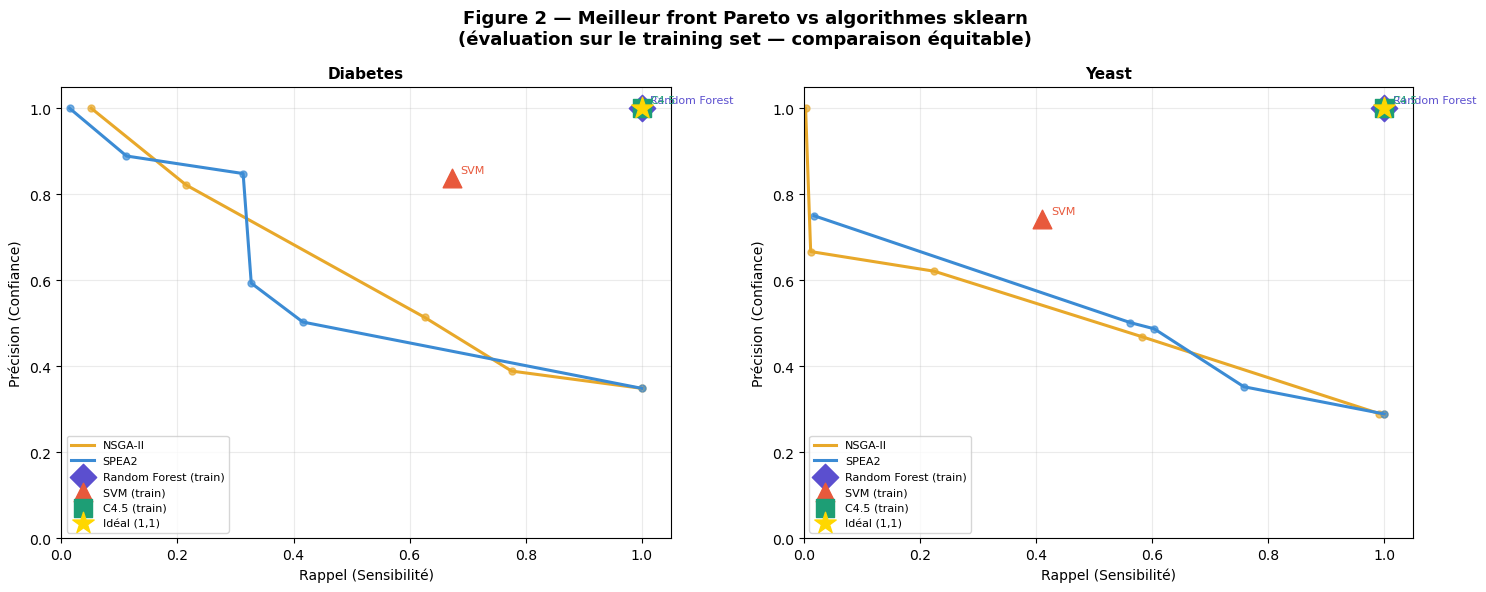

Figure 2 sauvegardée.


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figure 2 — Meilleur front Pareto vs algorithmes sklearn\n'
             '(évaluation sur le training set — comparaison équitable)',
             fontsize=13, fontweight='bold')

for ax, dataset_name in zip(axes, ['Diabetes', 'Yeast']):
    # Fronts Pareto des AG (meilleur run)
    for algo_name in ['NSGA-II', 'SPEA2']:
        front = best_fronts[dataset_name][algo_name]
        pts   = sorted([(-s.objectives[1], -s.objectives[0]) for s in front], key=lambda p: p[0])
        if pts:
            xs, ys = zip(*pts)
            ax.plot(xs, ys, color=ALGO_COLORS[algo_name], linewidth=2.2, label=algo_name)
            ax.scatter(xs, ys, color=ALGO_COLORS[algo_name], s=25, alpha=0.7)

    # Points sklearn (1 point par modèle)
    for model_name, m in sklearn_train[dataset_name].items():
        ax.scatter(m['Recall'], m['Precision'],
                   color=SKLEARN_COLORS[model_name],
                   marker=SKLEARN_MARKERS[model_name],
                   s=180, zorder=8, label=f'{model_name} (train)')
        ax.annotate(model_name, (m['Recall'], m['Precision']),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=8, color=SKLEARN_COLORS[model_name])

    ax.scatter([1], [1], marker='*', s=260, color='gold', zorder=9, label='Idéal (1,1)')
    ax.set_title(dataset_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Rappel (Sensibilité)'); ax.set_ylabel('Précision (Confiance)')
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=8, loc='lower left'); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('figure2_best_front_vs_sklearn_training.png', dpi=150)
plt.show()
print('Figure 2 sauvegardée.')

## 8.5 Figure 3 — Solution recommandée au décideur (meilleur F1)

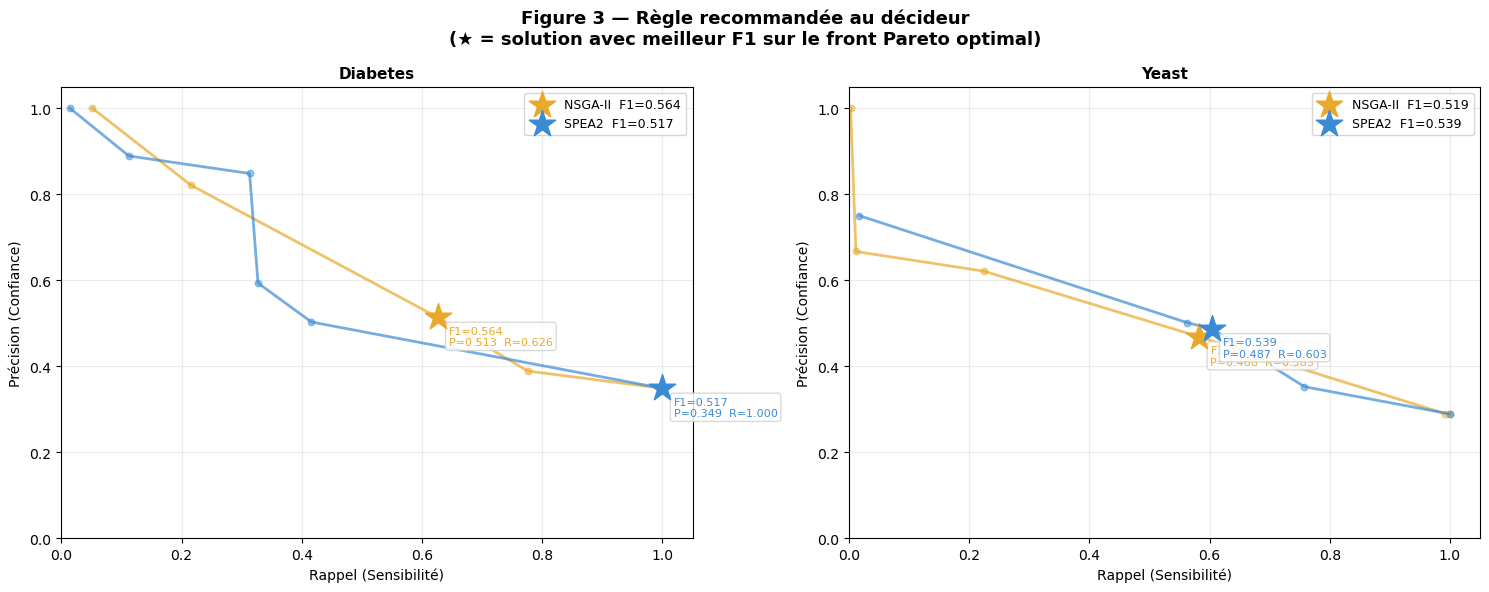

Figure 3 sauvegardée.


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Figure 3 — Règle recommandée au décideur\n'
             '(★ = solution avec meilleur F1 sur le front Pareto optimal)',
             fontsize=13, fontweight='bold')

for ax, dataset_name in zip(axes, ['Diabetes', 'Yeast']):
    for algo_name in ['NSGA-II', 'SPEA2']:
        front = best_fronts[dataset_name][algo_name]
        pts   = sorted([(-s.objectives[1], -s.objectives[0]) for s in front], key=lambda p: p[0])
        if pts:
            xs, ys = zip(*pts)
            ax.plot(xs, ys, color=ALGO_COLORS[algo_name], linewidth=2, alpha=0.7)
            ax.scatter(xs, ys, color=ALGO_COLORS[algo_name], s=22, alpha=0.5)

        # Solution recommandée (★)
        sol  = best_solutions[dataset_name][algo_name]
        prec = -sol.objectives[0]
        rec  = -sol.objectives[1]
        f1   = -sol.objectives[2]

        ax.scatter([rec], [prec], color=ALGO_COLORS[algo_name],
                   marker='*', s=400, zorder=8,
                   label=f'{algo_name}  F1={f1:.3f}')
        ax.annotate(
            f'F1={f1:.3f}\nP={prec:.3f}  R={rec:.3f}',
            (rec, prec), textcoords='offset points', xytext=(8, -20),
            fontsize=8, color=ALGO_COLORS[algo_name],
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85, ec='lightgray')
        )

    ax.set_title(dataset_name, fontsize=11, fontweight='bold')
    ax.set_xlabel('Rappel (Sensibilité)'); ax.set_ylabel('Précision (Confiance)')
    ax.set_xlim(0, 1.05); ax.set_ylim(0, 1.05)
    ax.legend(fontsize=9); ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('figure3_solution_recommandee.png', dpi=150)
plt.show()
print('Figure 3 sauvegardée.')

## 8.6 Évaluation sur le TEST set + Tableau comparatif final

In [28]:
datasets_test = {
    'Diabetes': (X_test_diabetes, y_test_diabetes),
    'Yeast':    (X_test_yeast,    y_test_yeast),
}
results_test = {
    'Diabetes': results_diabetes,
    'Yeast':    results_yeast,
}
results_test_scaled = {
    'Diabetes': X_test_diabetes_scaled,
    'Yeast':    X_test_yeast_scaled,
}
results_test_X = {
    'Diabetes': X_test_diabetes,
    'Yeast':    X_test_yeast,
}

comparison_rows = []

for dataset_name in ['Diabetes', 'Yeast']:
    X_te  = results_test_X[dataset_name]
    X_sc  = results_test_scaled[dataset_name]
    y_te  = datasets_test[dataset_name][1]
    res_sk = results_test[dataset_name]

    # ── Sklearn (test) ───────────────────────────────────────────────────
    for model_name, res in res_sk.items():
        y_pr = res['y_pred']
        hv_best = max(
            hypervolume_2d(best_fronts[dataset_name][ag])
            for ag in algorithms_dict
        )
        comparison_rows.append({
            'Dataset':    dataset_name,
            'Algorithme': model_name,
            'Type':       'Boîte noire' if model_name in ['Random Forest','SVM'] else 'Boîte blanche',
            'Confiance (P)':   round(precision_score(y_te, y_pr, zero_division=0), 4),
            'Sensibilité (R)': round(recall_score(y_te,    y_pr, zero_division=0), 4),
            'F1-mesure':       round(f1_score(y_te,         y_pr, zero_division=0), 4),
            'Hypervolume':     '/',
            'Pop size':        '/',
        })

    # ── AG (test) ────────────────────────────────────────────────────────
    for algo_name in algorithms_dict:
        sol      = best_solutions[dataset_name][algo_name]
        best_hv  = max(r[0] for r in all_runs[dataset_name][algo_name])
        best_ps  = best_pop_size[dataset_name][algo_name]
        test_m   = evaluate_solution_on_set(sol, X_te, y_te)
        comparison_rows.append({
            'Dataset':    dataset_name,
            'Algorithme': algo_name,
            'Type':       'Évolutionnaire',
            'Confiance (P)':   round(test_m['Precision'], 4),
            'Sensibilité (R)': round(test_m['Recall'],    4),
            'F1-mesure':       round(test_m['F1'],        4),
            'Hypervolume':     round(best_hv, 4),
            'Pop size':        best_ps,
        })

df_final = pd.DataFrame(comparison_rows)
print('=== TABLEAU COMPARATIF FINAL (TEST SET) — à mettre dans le rapport ===')
print(df_final.to_string(index=False))

=== TABLEAU COMPARATIF FINAL (TEST SET) — à mettre dans le rapport ===
 Dataset    Algorithme           Type  Confiance (P)  Sensibilité (R)  F1-mesure Hypervolume Pop size
Diabetes Random Forest    Boîte noire         0.7273           0.5926     0.6531           /        /
Diabetes           SVM    Boîte noire         0.6522           0.5556     0.6000           /        /
Diabetes          C4.5  Boîte blanche         0.5385           0.5185     0.5283           /        /
Diabetes       NSGA-II Évolutionnaire         0.5397           0.6296     0.5812      0.5332      100
Diabetes         SPEA2 Évolutionnaire         0.3506           1.0000     0.5192      0.5282       76
   Yeast Random Forest    Boîte noire         0.6607           0.4302     0.5211           /        /
   Yeast           SVM    Boîte noire         0.7442           0.3721     0.4961           /        /
   Yeast          C4.5  Boîte blanche         0.6234           0.5581     0.5890           /        /
   Yeast   

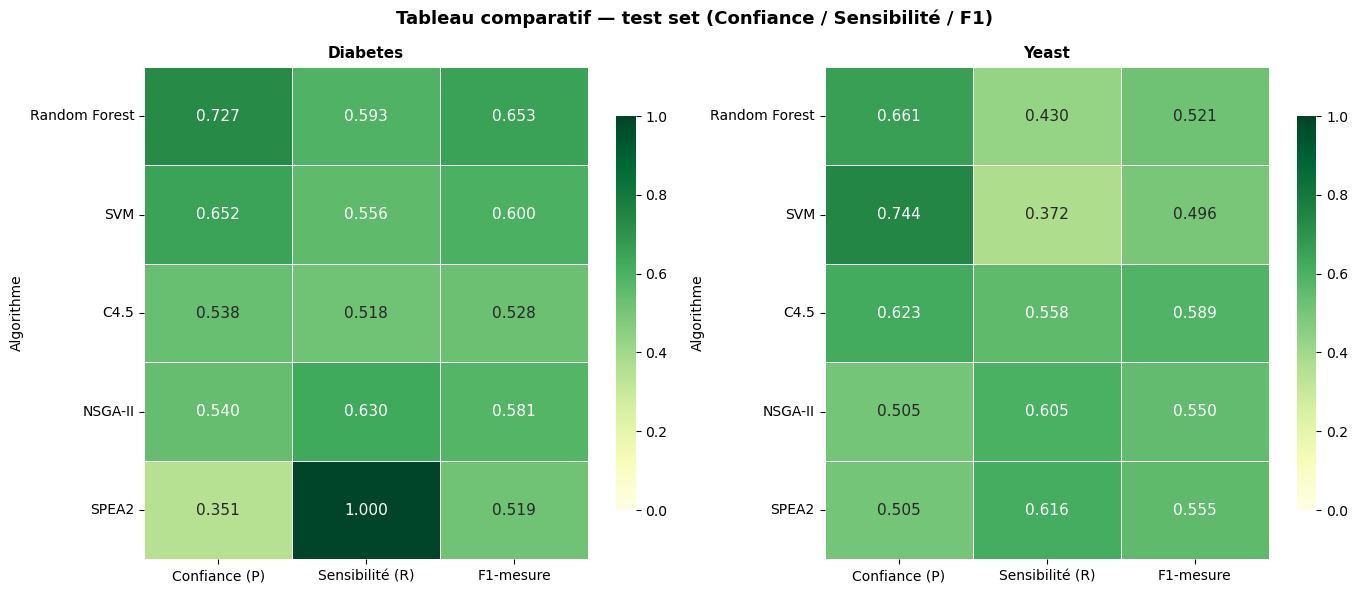

Tableau comparatif final sauvegardé.


In [29]:
# ── Heatmap du tableau comparatif ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Tableau comparatif — test set (Confiance / Sensibilité / F1)',
             fontsize=13, fontweight='bold')

for ax, dataset_name in zip(axes, ['Diabetes', 'Yeast']):
    subset = df_final[df_final['Dataset'] == dataset_name].set_index('Algorithme')
    cols   = ['Confiance (P)', 'Sensibilité (R)', 'F1-mesure']
    matrix = subset.reindex(ALGO_ORDER)[cols].astype(float)

    sns.heatmap(matrix, annot=True, fmt='.3f', cmap='YlGn',
                ax=ax, vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={'shrink': 0.8}, annot_kws={'size': 11})
    ax.set_title(dataset_name, fontsize=11, fontweight='bold')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('tableau_comparatif_final.png', dpi=150)
plt.show()
print('Tableau comparatif final sauvegardé.')

# 9. Interprétabilité — Règle extraite pour le décideur

In [30]:
def decode_rule(solution, feature_names, dataset_name, algo_name):
    """
    Décode les variables d'une solution en règle lisible.
    Un attribut est ACTIF si bi <= bs (il restreint l'espace).
    """
    variables = solution.variables
    n_attr = len(variables) // 2
    prec = -solution.objectives[0]
    rec  = -solution.objectives[1]
    f1   = -solution.objectives[2]

    print(f'\n{'='*60}')
    print(f'Dataset : {dataset_name}  |  Algorithme : {algo_name}')
    print(f'Métriques (training) :  Précision={prec:.4f}  Rappel={rec:.4f}  F1={f1:.4f}')
    print(f'{'='*60}')
    print('RÈGLE INTERPRÉTABLE :')
    print('Une instance est classifiée POSITIVE si :')
    print()

    active_attrs = []
    for i in range(n_attr):
        bi = variables[2 * i]
        bs = variables[2 * i + 1]
        if bi <= bs:   # attribut actif
            active_attrs.append((feature_names[i], bi, bs))

    if not active_attrs:
        print('  (aucun attribut actif — toutes les instances sont positives)')
    else:
        for j, (name, bi, bs) in enumerate(active_attrs):
            connector = 'ET' if j < len(active_attrs) - 1 else '   '
            print(f'  {bi:8.3f}  <=  {name:<25s}  <=  {bs:8.3f}  {connector}')

    print()
    print(f'Attributs ACTIFS   : {len(active_attrs)} / {n_attr}')
    print(f'Attributs INACTIFS : {n_attr - len(active_attrs)} / {n_attr}')
    print(f'(un attribut inactif = bi > bs = non contraignant)')


feature_names = {
    'Diabetes': list(X_diabetes.columns),
    'Yeast':    list(X_yeast.columns),
}

# Afficher la règle de chaque meilleure solution
for dataset_name in ['Diabetes', 'Yeast']:
    for algo_name in ['NSGA-II', 'SPEA2']:
        decode_rule(
            best_solutions[dataset_name][algo_name],
            feature_names[dataset_name],
            dataset_name, algo_name
        )


Dataset : Diabetes  |  Algorithme : NSGA-II
Métriques (training) :  Précision=0.5134  Rappel=0.6262  F1=0.5642
RÈGLE INTERPRÉTABLE :
Une instance est classifiée POSITIVE si :

   119.941  <=  Glucose                    <=   181.387     

Attributs ACTIFS   : 1 / 8
Attributs INACTIFS : 7 / 8
(un attribut inactif = bi > bs = non contraignant)

Dataset : Diabetes  |  Algorithme : SPEA2
Métriques (training) :  Précision=0.3485  Rappel=1.0000  F1=0.5169
RÈGLE INTERPRÉTABLE :
Une instance est classifiée POSITIVE si :

  (aucun attribut actif — toutes les instances sont positives)

Attributs ACTIFS   : 0 / 8
Attributs INACTIFS : 8 / 8
(un attribut inactif = bi > bs = non contraignant)

Dataset : Yeast  |  Algorithme : NSGA-II
Métriques (training) :  Précision=0.4684  Rappel=0.5831  F1=0.5195
RÈGLE INTERPRÉTABLE :
Une instance est classifiée POSITIVE si :

     0.262  <=  Nuc                        <=     0.939     

Attributs ACTIFS   : 1 / 8
Attributs INACTIFS : 7 / 8
(un attribut inactif =

In [32]:
# ── Comparaison du nombre d'attributs actifs (complexité de la règle) ────
print('\n=== COMPLEXITÉ DES RÈGLES (attributs actifs) ===')
print(f'{"":<30}  {"#Actifs":>8}  {"#Inactifs":>10}  {"Simplicité":>12}')
print('-'*64)
for dataset_name in ['Diabetes', 'Yeast']:
    n_total = len(feature_names[dataset_name])
    for algo_name in ['NSGA-II', 'SPEA2']:
        sol = best_solutions[dataset_name][algo_name]
        variables = sol.variables
        n_active = sum(
            1 for i in range(n_total)
            if variables[2*i] <= variables[2*i+1]
        )
        pct_simple = round(100 * (1 - n_active / n_total), 1)
        print(f'  {dataset_name:10s} {algo_name:8s}  '
              f'{n_active:>8d}  {n_total - n_active:>10d}  '
              f'{pct_simple:>10.1f}%')
    print()



=== COMPLEXITÉ DES RÈGLES (attributs actifs) ===
                                 #Actifs   #Inactifs    Simplicité
----------------------------------------------------------------
  Diabetes   NSGA-II          1           7        87.5%
  Diabetes   SPEA2            0           8       100.0%

  Yeast      NSGA-II          1           7        87.5%
  Yeast      SPEA2            4           4        50.0%



## 10. Visualisations complémentaires

## 10.1 Comparaison des baselines sklearn (Accuracy & AUC)

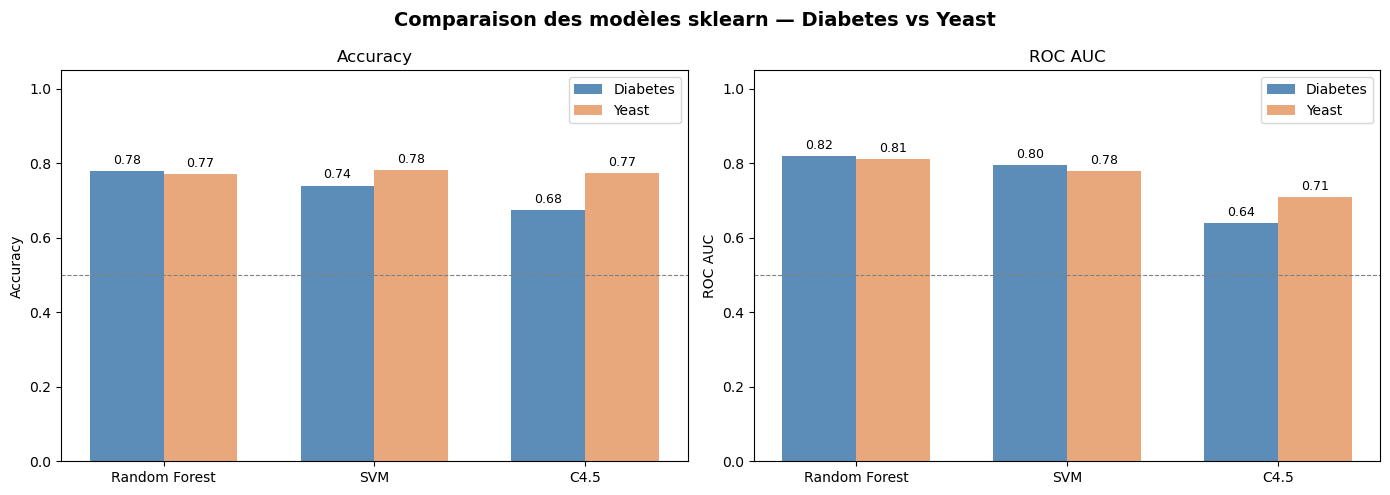

In [34]:
results_sklearn_dict = {'Diabetes': results_diabetes, 'Yeast': results_yeast}
metrics_sk   = ['Accuracy', 'ROC AUC']
model_names  = ['Random Forest', 'SVM', 'C4.5']
x     = np.arange(len(model_names))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Comparaison des modèles sklearn — Diabetes vs Yeast',
             fontsize=14, fontweight='bold')

for ax, metric in zip(axes, metrics_sk):
    bars_d = [results_diabetes[m][metric] for m in model_names]
    bars_y = [results_yeast[m][metric]    for m in model_names]

    ax.bar(x - width/2, bars_d, width, label='Diabetes', color='#5B8DB8')
    ax.bar(x + width/2, bars_y, width, label='Yeast',    color='#E8A87C')

    ax.set_title(metric)
    ax.set_xticks(x)                            
    ax.set_xticklabels(model_names)
    ax.set_ylim(0, 1.05); ax.set_ylabel(metric)
    ax.legend()
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)

    for bar in ax.patches:
        ax.annotate(f'{bar.get_height():.2f}',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('comparison_metrics.png', dpi=150)
plt.show()

# 10.2 Courbes ROC

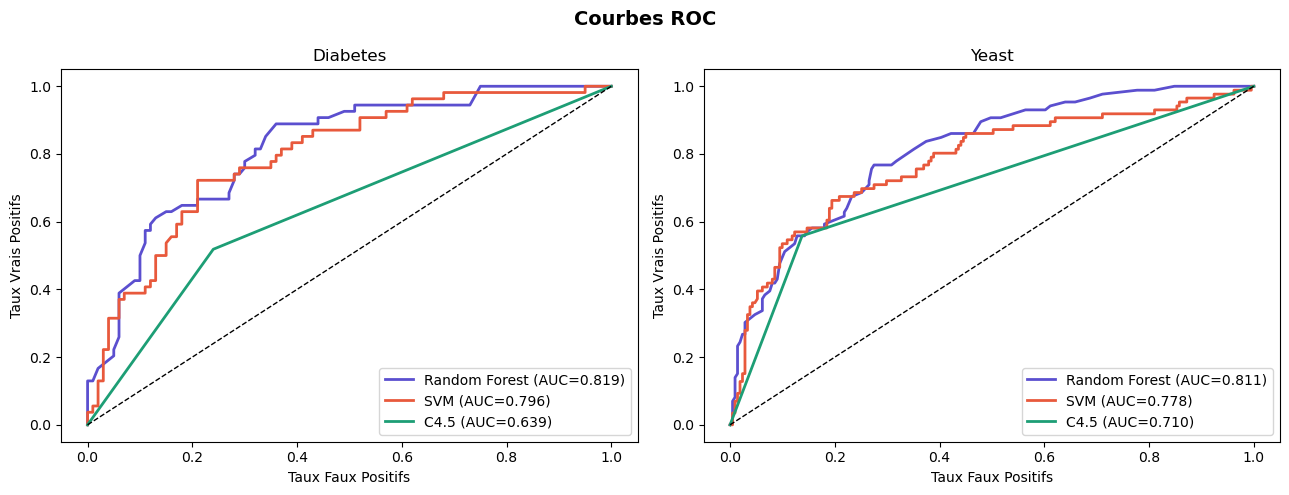

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Courbes ROC', fontsize=14, fontweight='bold')

for ax, (dataset_name, results) in zip(axes, results_sklearn_dict.items()):
    y_test_ref = y_test_diabetes if dataset_name == 'Diabetes' else y_test_yeast
    for model_name, res in results.items():
        fpr, tpr, _ = roc_curve(y_test_ref, res['y_prob'])
        ax.plot(fpr, tpr, lw=2, color=SKLEARN_COLORS[model_name],
                label=f'{model_name} (AUC={res["ROC AUC"]:.3f})')

    ax.plot([0,1],[0,1],'k--', lw=1)
    ax.set_title(dataset_name)
    ax.set_xlabel('Taux Faux Positifs'); ax.set_ylabel('Taux Vrais Positifs')
    ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150)
plt.show()

# 10.3 Distribution F1 sur les fronts Pareto (tous les 20 runs)

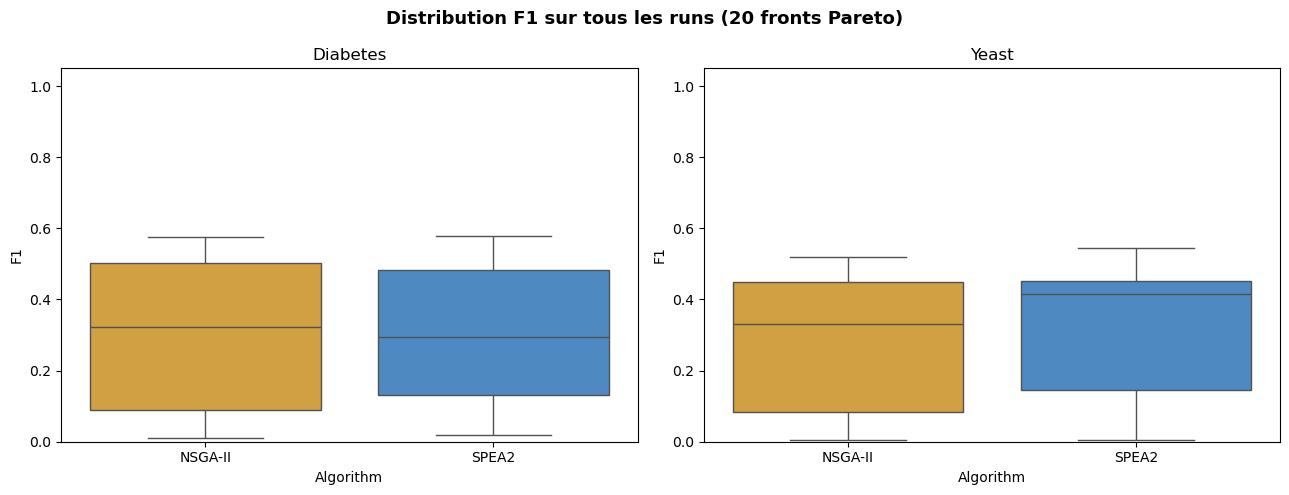

In [36]:
# Construction d'un DataFrame avec tous les runs
df_all_runs = []
for dataset_name in ['Diabetes', 'Yeast']:
    for algo_name in ['NSGA-II', 'SPEA2']:
        for hv, front in all_runs[dataset_name][algo_name]:
            for sol in front:
                df_all_runs.append({
                    'Dataset':   dataset_name,
                    'Algorithm': algo_name,
                    'Precision': -sol.objectives[0],
                    'Recall':    -sol.objectives[1],
                    'F1':        -sol.objectives[2],
                })
df_all_runs = pd.DataFrame(df_all_runs)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribution F1 sur tous les runs (20 fronts Pareto)',
             fontsize=13, fontweight='bold')

for ax, dataset_name in zip(axes, ['Diabetes', 'Yeast']):
    subset = df_all_runs[df_all_runs['Dataset'] == dataset_name]
    # CORRECTION seaborn : utiliser hue= au lieu de palette= sans hue
    sns.boxplot(
        data=subset, x='Algorithm', y='F1', ax=ax,
        hue='Algorithm',
        palette={'NSGA-II': ALGO_COLORS['NSGA-II'], 'SPEA2': ALGO_COLORS['SPEA2']},
        legend=False
    )
    ax.set_title(dataset_name); ax.set_ylim(0, 1.05); ax.set_ylabel('F1')

plt.tight_layout()
plt.savefig('f1_boxplot_all_runs.png', dpi=150)
plt.show()

## 10.4 Heatmap générale

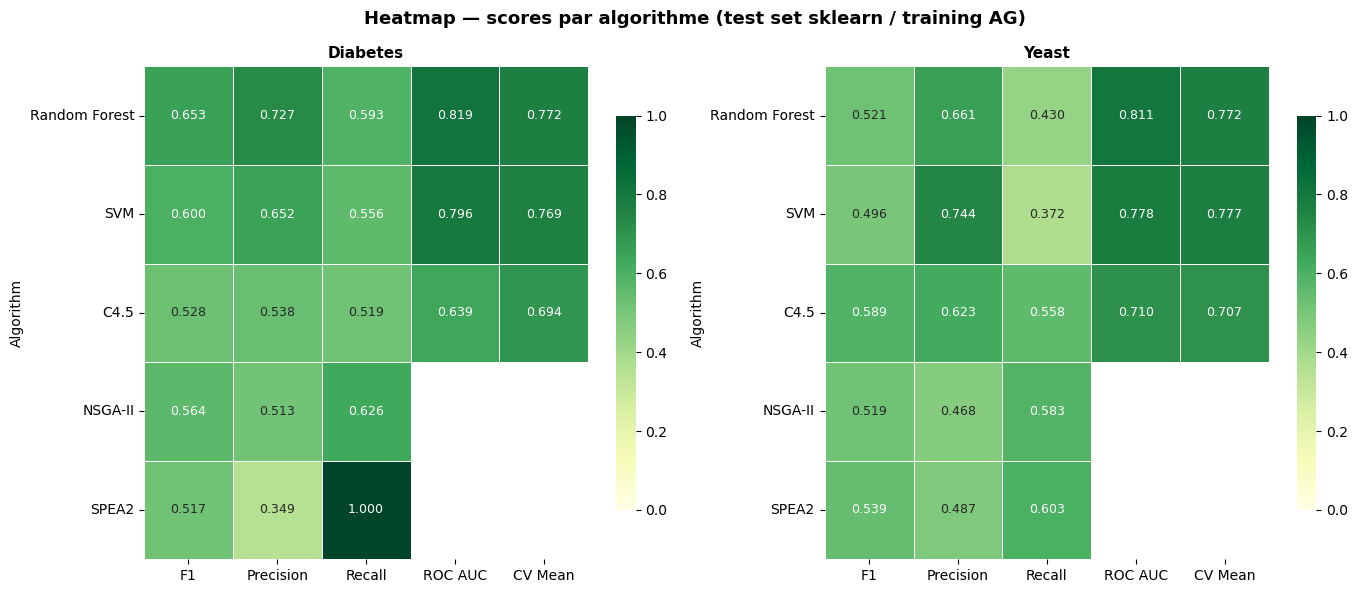

In [37]:
rows_all = []

for dataset_name in ['Diabetes', 'Yeast']:
    y_te   = y_test_diabetes if dataset_name == 'Diabetes' else y_test_yeast
    res_sk = results_diabetes if dataset_name == 'Diabetes' else results_yeast

    for model_name, res in res_sk.items():
        rows_all.append({
            'Dataset':   dataset_name, 'Algorithm': model_name,
            'F1':        f1_score(y_te, res['y_pred'], zero_division=0),
            'Precision': precision_score(y_te, res['y_pred'], zero_division=0),
            'Recall':    recall_score(y_te, res['y_pred'], zero_division=0),
            'ROC AUC':   res['ROC AUC'],
            'CV Mean':   res['CV Mean'],
        })

    for algo_name in ['NSGA-II', 'SPEA2']:
        sol = best_solutions[dataset_name][algo_name]
        rows_all.append({
            'Dataset':   dataset_name, 'Algorithm': algo_name,
            'F1':       -sol.objectives[2],
            'Precision':-sol.objectives[0],
            'Recall':   -sol.objectives[1],
            'ROC AUC':  None,
            'CV Mean':  None,
        })

df_all_metrics = pd.DataFrame(rows_all)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Heatmap — scores par algorithme (test set sklearn / training AG)',
             fontsize=13, fontweight='bold')

for ax, dataset_name in zip(axes, ['Diabetes', 'Yeast']):
    subset = df_all_metrics[df_all_metrics['Dataset'] == dataset_name].set_index('Algorithm')
    matrix = subset.reindex(ALGO_ORDER)[['F1','Precision','Recall','ROC AUC','CV Mean']].astype(float)

    sns.heatmap(matrix, annot=True, fmt='.3f', cmap='YlGn',
                ax=ax, vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={'shrink': 0.8}, annot_kws={'size': 9})
    ax.set_title(dataset_name, fontsize=11, fontweight='bold')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('heatmap_all.png', dpi=150)
plt.show()